# CNN-LSTM Hybrid — Many-to-One Energy Price Forecasting

This notebook extends the earlier RNN/LSTM/GRU set with a **CNN-LSTM hybrid**:
a 1D convolution stage extracts local, position-independent temporal patterns
(short-lived spikes, ramps, daily-cycle edges) from the 24-hour input window,
then an LSTM models the longer-range dependencies across what the convolution
extracted, and a Dense layer produces the final forecast. Same dataset, same
many-to-one task (24h window -> next-hour price), same `FEATURE_COLS`/`TARGET_COL`
as `02_lstm_energy_forecasting.ipynb`, so results are directly comparable.

## 1. Why combine CNN and LSTM?

A plain LSTM reads the window one timestep at a time and must learn to notice
local patterns (like a sudden ramp in wind generation) purely through its
recurrent state. A **1D convolution** (`Conv1D`) instead slides a small filter
of width `KERNEL_SIZE` across the time axis, computing the same local pattern
detector at every position — exactly like a CNN's spatial filters, but along
time instead of space. This gives two practical benefits: (1) local patterns
are detected regardless of *where* in the window they occur (translation
invariance along time), and (2) `MaxPooling1D` then downsamples the sequence,
so the LSTM that follows has a *shorter*, pre-summarized sequence to reason
over — often easier to learn from than 24 raw timesteps.

The resulting pipeline is:

```
Input (24, 5) -> Conv1D + ReLU -> MaxPooling1D -> LSTM -> Dense(1) -> forecast
```

`padding="causal"` on the `Conv1D` layer matters for forecasting specifically:
it pads only on the left (past) side, so the filter centered at position *t*
never looks at position *t+1* or later — no future leakage into the features
the LSTM subsequently sees.

## 1b. Setup and Imports

Model architecture diagrams (`show_model_diagram`) need `pydot` and the Graphviz `dot` executable. If missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
sudo apt-get install graphviz   # Debian/Ubuntu
```

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

This is the same dataset and the same many-to-one task (24 hours of history ->
next-hour price) used in the companion `01_vanilla_rnn`, `02_lstm`, and
`03_gru` notebooks, so results here are directly comparable to those.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated).

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so
every cell in this notebook still runs end-to-end without the real file.

In [12]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset so the rest of "
              "the notebook still runs end-to-end.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

Using Colab cache for faster access to the 'energy-consumption-generation-prices-and-weather' dataset.
Downloaded via kagglehub to /kaggle/input/energy-consumption-generation-prices-and-weather/energy_dataset.csv
(35064, 28)


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [13]:
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 35064   Range: 2014-12-31 23:00:00 -> 2018-12-31 22:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,35064.0,28698.281385,4575.828854,18041.00,24807.0000,28902.00,32194.25,41015.0
generation solar,35064.0,1432.818546,1679.961733,0.00,71.0000,616.00,2579.00,5792.0
generation wind onshore,35064.0,5464.980450,3213.586296,0.00,2933.0000,4849.50,7399.50,17436.0
generation fossil gas,35064.0,5622.700647,2201.510984,0.00,4126.0000,4969.50,6429.00,20034.0
price actual,35064.0,57.884023,14.204083,9.33,49.3475,58.02,68.01,116.8


## 3. Feature Engineering & Scaling

Chronological (non-shuffled) train/val/test split, scaler fit on the training
slice only — identical setup to the earlier notebooks.

In [14]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=24544  val=5260  test=5260  n_features=5


## 4. Windowing (Many-to-One)

Same task as the `many_to_one` section of the RNN/LSTM/GRU notebooks: a
24-hour window of all 5 features predicts the single next-hour price.
`X` shape `(n, WINDOW, N_FEATURES)`, `y` shape `(n, 1)`.

In [15]:
def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


WINDOW = 24
UNITS = 32          # LSTM units, kept equal to the earlier LSTM notebook for a fair comparison
FILTERS = 32        # Conv1D filters
KERNEL_SIZE = 3
POOL_SIZE = 2
EPOCHS = 100
BATCH_SIZE = 64

Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

X shape: (24520, 24, 5)  y shape: (24520, 1)


In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}

_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Compiles with a fresh Adam optimizer, then fits. Use this for models
    that were NOT already compiled elsewhere (e.g. a plain baseline model)."""
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return fit_only(model, name, X_train, y_train, X_val, y_val, epochs)


def fit_only(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Fits a model that is ALREADY compiled (e.g. a Keras Tuner hypermodel,
    which is compiled with its own tuned optimizer/learning rate inside
    build_model() — recompiling it here would silently discard that tuning)."""
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    history_log[name] = history
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={history.history['val_mae'][-1]:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_pipeline(stages, title, figsize=(11, 2.6)):
    """A left-to-right layer-pipeline illustration: one box per stage, with its
    output shape written underneath, connected by arrows. Unlike the recurrent
    'unrolled cells' diagrams in the RNN/LSTM/GRU notebooks, a CNN-LSTM is best
    pictured as a pipeline of stages rather than per-timestep cells."""
    n = len(stages)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 1.7, 0.8
    xs = [i * 2.3 for i in range(n)]

    for i, (label, shape, color) in enumerate(stages):
        x = xs[i]
        box = FancyBboxPatch(
            (x - box_w / 2, -box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, 0.12, label, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
        ax.text(x, -0.22, shape, ha="center", va="center", fontsize=7.5, color="white")
        if i < n - 1:
            ax.annotate("", xy=(xs[i + 1] - box_w / 2, 0), xytext=(x + box_w / 2, 0),
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4))

    ax.set_xlim(xs[0] - 1.3, xs[-1] + 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis("off")
    ax.set_title(title, fontsize=10.5)
    plt.tight_layout()
    plt.show()

## 5. Baseline CNN-LSTM Model

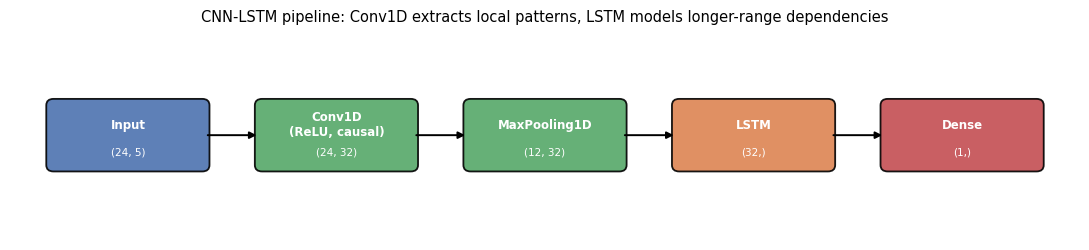

In [17]:
draw_pipeline(
    stages=[
        ("Input", "(24, 5)", "#4C72B0"),
        ("Conv1D\n(ReLU, causal)", f"(24, {FILTERS})", "#55A868"),
        ("MaxPooling1D", f"(12, {FILTERS})", "#55A868"),
        ("LSTM", f"({UNITS},)", "#DD8452"),
        ("Dense", "(1,)", "#C44E52"),
    ],
    title="CNN-LSTM pipeline: Conv1D extracts local patterns, LSTM models longer-range dependencies",
)

In [18]:
model_cnn_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation="relu", padding="causal"),
    tf.keras.layers.MaxPooling1D(pool_size=POOL_SIZE),
    tf.keras.layers.LSTM(UNITS, return_sequences=False),
    # --- Stack an additional Conv1D block before the LSTM: --------------------------
    tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation="relu", padding="causal"),
    tf.keras.layers.MaxPooling1D(pool_size=POOL_SIZE),
    # ---------------------------------------------------------------------------------
    tf.keras.layers.Dense(1),
], name="cnn_lstm_many_to_one")

model_cnn_lstm.summary()
show_model_diagram(model_cnn_lstm, "cnn_lstm_baseline.png")

ValueError: Input 0 with name 'None' of layer 'conv1d_4' is incompatible with the layer: expected min_ndim=3, found ndim=2. Full shape received: (None, 32)

Model: "cnn_lstm_B1_deeper_conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 24, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 12, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,969 (46.75 KB)

 Trainable params: 11,969 (46.75 KB)

 Non-trainable params: 0 (0.00 B)

cnn_lstm_B1_deeper_conv: ran 100/100 epochs  final val_loss=0.00092  val_mae=0.02240  params=11,969


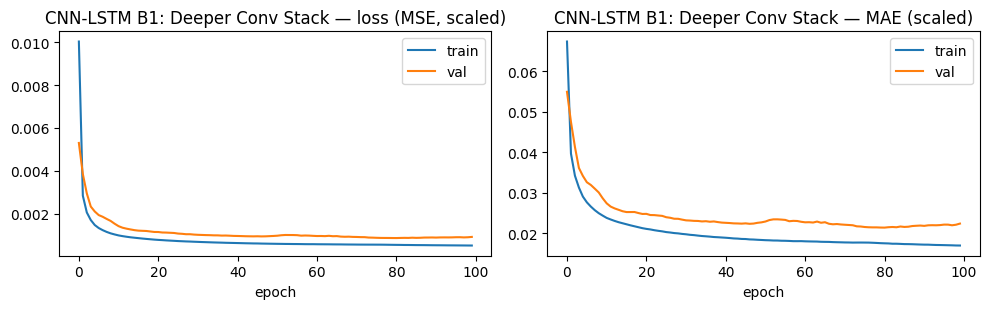

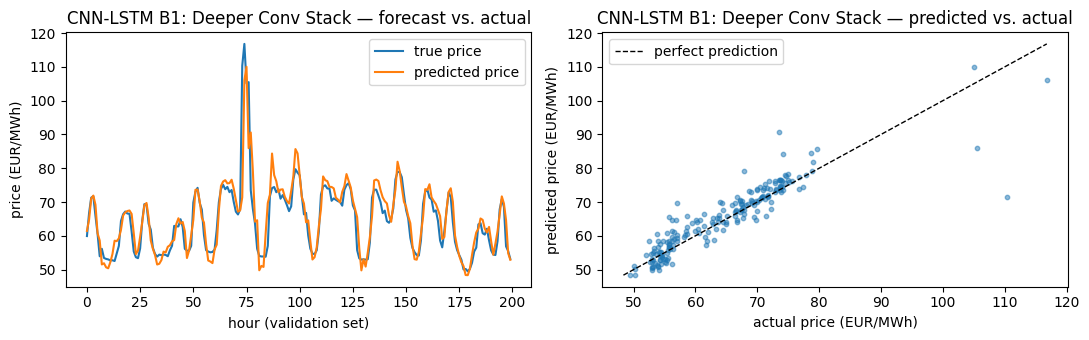

In [19]:
# ============================================================
# TASK B1 - DEEPEN THE CONV STACK
# Replace the original baseline model cell with this
# ============================================================

model_cnn_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),

    # Conv Block 1
    tf.keras.layers.Conv1D(
        filters=FILTERS,
        kernel_size=KERNEL_SIZE,
        activation="relu",
        padding="causal"
    ),
    tf.keras.layers.MaxPooling1D(
        pool_size=POOL_SIZE
    ),

    # Conv Block 2 (B1 change)
    tf.keras.layers.Conv1D(
        filters=FILTERS,
        kernel_size=KERNEL_SIZE,
        activation="relu",
        padding="causal"
    ),
    tf.keras.layers.MaxPooling1D(
        pool_size=POOL_SIZE
    ),

    # LSTM
    tf.keras.layers.LSTM(
        UNITS,
        return_sequences=False
    ),

    # Output
    tf.keras.layers.Dense(1)

], name="cnn_lstm_B1_deeper_conv")

model_cnn_lstm.summary()

hist_cnn_lstm = compile_and_fit(
    model_cnn_lstm,
    "cnn_lstm_B1_deeper_conv",
    Xm1,
    ym1,
    Xv_m1,
    yv_m1
)

plot_history(
    hist_cnn_lstm,
    "CNN-LSTM B1: Deeper Conv Stack"
)

pred = model_cnn_lstm.predict(
    Xv_m1,
    verbose=0
)

plot_point_prediction(
    yv_m1,
    pred,
    "CNN-LSTM B1: Deeper Conv Stack"
)

cnn_lstm_baseline: ran 100/100 epochs  final val_loss=0.00092  val_mae=0.02178  params=11,969


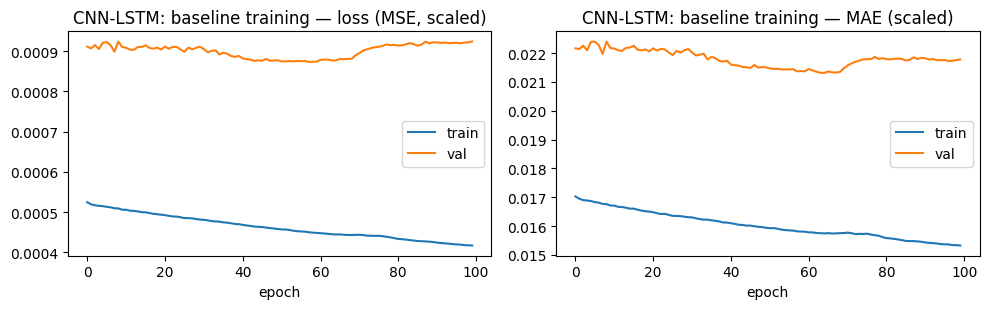

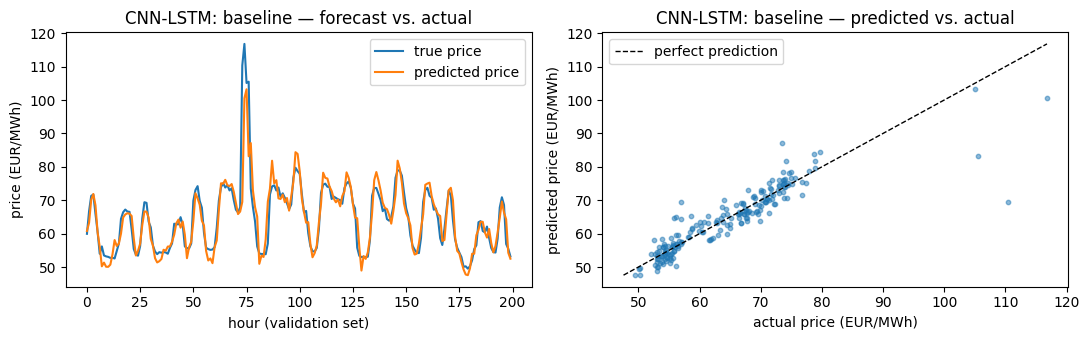

In [20]:
hist_cnn_lstm = compile_and_fit(model_cnn_lstm, "cnn_lstm_baseline", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_cnn_lstm, "CNN-LSTM: baseline training")

pred = model_cnn_lstm.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "CNN-LSTM: baseline")

## 6. Compare Against the Plain LSTM Notebook

Open `02_lstm_energy_forecasting.ipynb` and find the printed line for its
`many_to_one` architecture (`ran 100/100 epochs ... params=... val_loss=...`).
Compare that against this notebook's `cnn_lstm_baseline` line above, on the
**same 24h-window -> next-hour-price task**:

- Which model has more parameters, and why (think about what `Conv1D` and
  `MaxPooling1D` add beyond a plain `LSTM` layer)?
- Which achieved the lower validation loss on your run? A hybrid isn't
  automatically better — on a dataset this size, whether the extra Conv1D
  stage helps depends on how much genuinely local, position-independent
  structure is actually present in the 24-hour window.

The companion notebook `05_cnn_lstm_optimized_energy_forecasting.ipynb` picks
up from here and searches over this model's hyperparameters automatically.